# Analísis Exploratorio de Datos (EDA)

Explorar los datos limpios para comprender las relaciones entre las variables de supervivencia

In [141]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('data/titanic_data_dirty.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [142]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Supervivencia por Género

/var/folders/9c/f5s5n1w12bx8dbjw00ws47nr0000gn/T/ipykernel_39053/1505180528.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, palette='viridis')


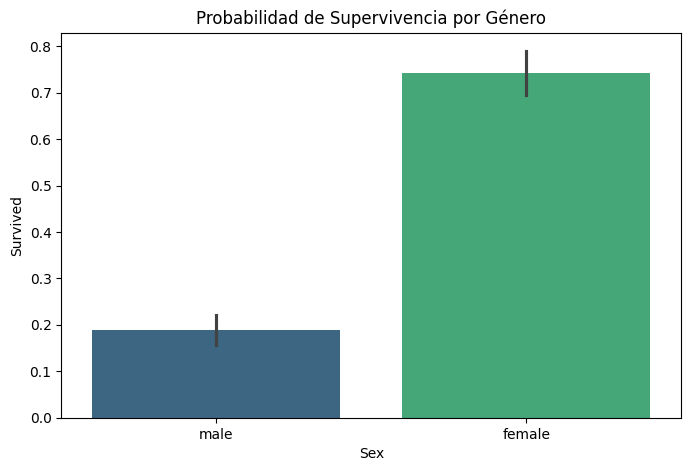

In [143]:
plt.figure(figsize=(8,5))
sns.barplot(x='Sex', y='Survived', data=df, palette='viridis')
plt.title('Probabilidad de Supervivencia por Género')
plt.show()

# Probabilidad de Supervivencia por Clase

/var/folders/9c/f5s5n1w12bx8dbjw00ws47nr0000gn/T/ipykernel_39053/3078854192.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y= 'Survived', data=df, palette='magma')


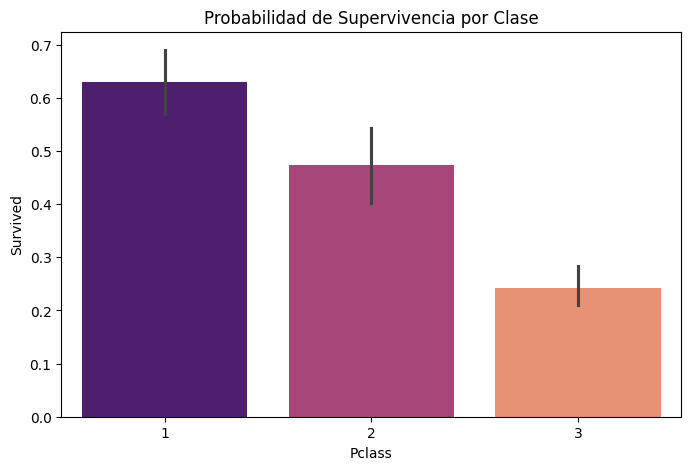

In [144]:
plt.figure(figsize=(8,5))
sns.barplot(x='Pclass', y= 'Survived', data=df, palette='magma')
plt.title('Probabilidad de Supervivencia por Clase')
plt.show()

# Distribución de las edades en el barco

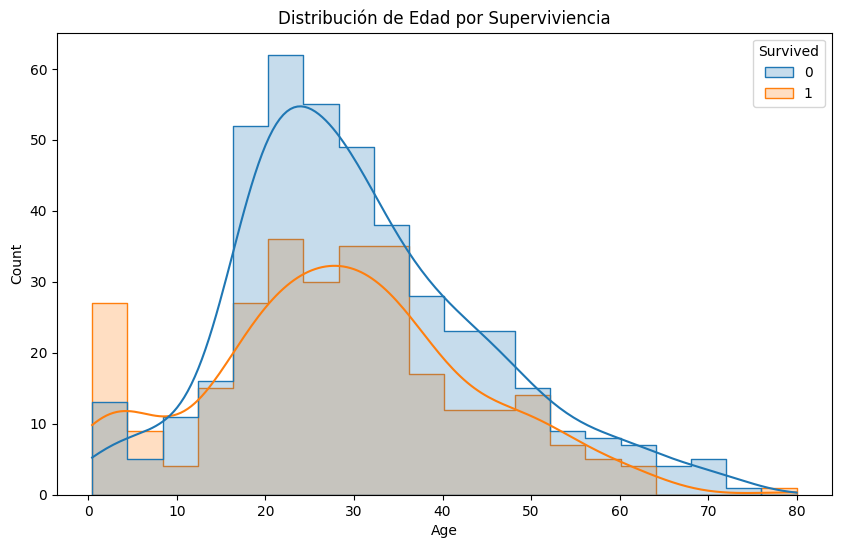

In [145]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Age', hue= 'Survived', kde=True, element='step')
plt.title('Distribución de Edad por Superviviencia')
plt.show()

---

# 4. Tratamiento de valores nulos

El diagnóstico anterior reveló tres columnas con datos ausentes:

| Columna | Nulos | % | Decisión |
|---|---:|---:|---|
| `Cabin` | 687 | 77.1 % | **Eliminar** — con más de tres cuartas partes ausente no hay información suficiente para reconstruirla sin inventarla |
| `Age` | 177 | 19.9 % | **Imputar** — es una quinta parte de los datos; descartar esas filas costaría demasiada potencia estadística |
| `Embarked` | 2 | 0.2 % | **Imputar** — irrelevante en volumen, pero hay que resolverlo |

También eliminamos `Ticket`: es un identificador alfanumérico sin estructura consistente, no una variable con poder predictivo.

**La pregunta central de esta sección:** ¿con qué valor rellenamos los 177 huecos de `Age` sin deformar la distribución?

## 4.1 Por qué imputar con un valor constante deforma la distribución

La solución habitual es rellenar con la media o la mediana. Es rápida, pero tiene una consecuencia matemática que se puede demostrar antes de ejecutar nada.

Supón que tienes $n_{obs}$ valores observados con varianza muestral $s^2$, y rellenas $n_{mis}$ huecos con la media $\bar{x}$. La varianza se define como:

$$s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2$$

Cada valor imputado es exactamente $\bar{x}$, así que aporta $(\bar{x} - \bar{x})^2 = 0$ a la suma. **El numerador no cambia, pero el denominador crece.** El resultado:

$$s^2_{\text{imputada}} = s^2_{\text{observada}} \cdot \frac{n_{obs} - 1}{n_{obs} + n_{mis} - 1}$$

Es decir, la varianza se contrae por un factor conocido de antemano. Verifiquémoslo numéricamente.

In [146]:
import numpy as np

edad_obs = df['Age'].dropna()
n_obs = edad_obs.size
n_mis = int(df['Age'].isna().sum())

s_obs = edad_obs.std(ddof=1)
factor = np.sqrt((n_obs - 1) / (n_obs + n_mis - 1))

print(f"Valores observados : n = {n_obs}   |  desv. estándar = {s_obs:.3f}")
print(f"Valores faltantes  : n = {n_mis}")
print()
print(f"Factor de contracción teórico = sqrt({n_obs-1}/{n_obs+n_mis-1}) = {factor:.4f}")
print(f"Desv. estándar PREDICHA tras imputar con la media : {s_obs * factor:.3f}")

s_medido = df['Age'].fillna(edad_obs.mean()).std(ddof=1)
print(f"Desv. estándar MEDIDA                             : {s_medido:.3f}")

Valores observados : n = 714   |  desv. estándar = 14.526
Valores faltantes  : n = 177

Factor de contracción teórico = sqrt(713/890) = 0.8951
Desv. estándar PREDICHA tras imputar con la media : 13.002
Desv. estándar MEDIDA                             : 13.002


La predicción y la medición coinciden: rellenar con una constante **garantiza** perder cerca del 10 % de la dispersión. No es un efecto secundario aleatorio, es aritmética.

¿Por qué importa? Porque un modelo aprende de la variabilidad. Si le entregas 177 pasajeros con edad idéntica, le enseñas una regularidad que no existe en la realidad, y la relación entre `Age` y la supervivencia se aplana.

## 4.2 Imputación estocástica por regresión

La alternativa es predecir cada edad faltante a partir del resto de variables, y **devolverle la aleatoriedad** que una observación real tendría:

$$\widehat{Age}_i = f(X_i) + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0, \sigma^2_{res})$$

Dos piezas:

1. **$f(X_i)$** — una regresión lineal entrenada sobre los 714 pasajeros con edad conocida. Predice la *media condicional*: dada la clase, el sexo, la tarifa y los familiares a bordo, ¿qué edad esperamos?

2. **$\varepsilon_i$** — un residuo aleatorio. Sin él, todos los imputados caerían exactamente sobre el hiperplano de regresión y volveríamos a aplastar la varianza, solo que de forma más elegante. La desviación $\sigma_{res}$ se estima de forma **insesgada**, dividiendo entre los grados de libertad y no entre $n$:

$$\sigma_{res} = \sqrt{\frac{\sum_i (y_i - \hat{y}_i)^2}{n - p - 1}}$$

donde $p$ es el número de predictores. Dividir entre $n$ subestimaría la dispersión precisamente porque el modelo ya se ajustó a esos datos.

In [147]:
# Preparación: eliminamos las columnas acordadas y normalizamos los nombres a minúsculas.
# Trabajamos sobre una copia para conservar intacto `df` (el crudo) y poder comparar después.

df_clean = df.drop(columns=['Ticket', 'Cabin']).copy()
df_clean.columns = df_clean.columns.str.lower()

print("Columnas resultantes:", list(df_clean.columns))
print("Nulos restantes por columna:")
print(df_clean.isna().sum()[lambda s: s > 0])

Columnas resultantes: ['passengerid', 'survived', 'pclass', 'name', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
Nulos restantes por columna:
age         177
embarked      2
dtype: int64


In [148]:
import re
from sklearn.linear_model import LinearRegression

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

# --- Predictor extra: el título social contenido en el nombre -------------------
# 'Master' identifica a niños varones y 'Miss' a mujeres jóvenes o solteras.
# Es la señal más fuerte disponible para estimar la edad, y sale gratis del nombre.
TITULOS = {'Mr', 'Mrs', 'Miss', 'Master'}

def extraer_titulo(nombre):
    m = re.search(r' ([A-Za-z]+)\.', nombre)
    return m.group(1) if m and m.group(1) in TITULOS else 'Otro'

df_clean['_titulo'] = df_clean['name'].apply(extraer_titulo)
print(df_clean['_titulo'].value_counts(), end='\n\n')

# --- Embarked: sorteo desde la distribución empírica ----------------------------
# Con solo 2 nulos la moda bastaría, pero muestrear de las proporciones observadas
# mantiene la composición original del puerto en lugar de inflar el más frecuente.
faltan_emb = df_clean['embarked'].isna()
props = df_clean['embarked'].dropna().value_counts(normalize=True)
df_clean.loc[faltan_emb, 'embarked'] = rng.choice(props.index, size=int(faltan_emb.sum()), p=props.to_numpy())

# --- Age: regresión + ruido -----------------------------------------------------
PREDICTORES = ['pclass', 'sex', 'sibsp', 'parch', 'fare', 'embarked', '_titulo']
X = pd.get_dummies(df_clean[PREDICTORES],
                   columns=['sex', 'embarked', '_titulo', 'pclass'],
                   drop_first=True).astype(float)
y = df_clean['age']
observado = y.notna()

modelo = LinearRegression().fit(X[observado], y[observado])

residuos = y[observado] - modelo.predict(X[observado])
gl = observado.sum() - X.shape[1] - 1          # grados de libertad
sigma_res = np.sqrt((residuos ** 2).sum() / gl)

prediccion = modelo.predict(X[~observado])
ruido = rng.normal(0.0, sigma_res, size=int((~observado).sum()))
imputados = np.clip(prediccion + ruido, 0.42, 80.0)   # rango observado en los datos reales

df_clean.loc[~observado, 'age'] = imputados
df_clean = df_clean.drop(columns=['_titulo'])         # solo servía para imputar

print(f"R² del modelo de edad : {modelo.score(X[observado], y[observado]):.3f}")
print(f"sigma_residual        : {sigma_res:.2f} años")
print(f"Valores imputados     : {int((~observado).sum())}")
print(f"Nulos restantes       : {int(df_clean.isna().sum().sum())}")

_titulo
Mr        517
Miss      182
Mrs       125
Master     40
Otro       27
Name: count, dtype: int64

R² del modelo de edad : 0.426
sigma_residual        : 11.10 años
Valores imputados     : 177
Nulos restantes       : 0


## 4.3 Las tres estrategias comparadas

Con el resultado en mano, contrastamos la imputación estocástica contra las dos alternativas simples. Comparamos los **cuatro primeros momentos** de la distribución, porque cada uno captura un aspecto distinto de la deformación:

- **Desviación estándar** — cuánta dispersión conservamos
- **Media** — si el centro se desplaza
- **Asimetría** *(skewness)* — si la cola se deforma
- **Curtosis** — **qué tan puntiaguda queda la distribución**; este es el número que delata el pico artificial en el centro

In [149]:
imp_global = df['Age'].fillna(df['Age'].median())
imp_grupo = df['Age'].fillna(df.groupby(['Pclass', 'Sex'])['Age'].transform('median'))
imp_estoc = df_clean['age']

momentos = pd.DataFrame({
    'Observados (714)':    [edad_obs.std(), edad_obs.mean(), edad_obs.skew(), edad_obs.kurtosis()],
    'A. Mediana global':   [imp_global.std(), imp_global.mean(), imp_global.skew(), imp_global.kurtosis()],
    'B. Mediana x grupo':  [imp_grupo.std(), imp_grupo.mean(), imp_grupo.skew(), imp_grupo.kurtosis()],
    'C. Estocástica':      [imp_estoc.std(), imp_estoc.mean(), imp_estoc.skew(), imp_estoc.kurtosis()],
}, index=['desv_estándar', 'media', 'asimetría', 'curtosis'])

print(momentos.round(3).to_string())

print("\n--- Concentración de masa en un solo punto ---")
for nombre, serie in [('A. Mediana global', imp_global),
                      ('B. Mediana x grupo', imp_grupo),
                      ('C. Estocástica', imp_estoc)]:
    top = serie.value_counts().head(1)
    print(f"{nombre:20}: la edad {top.index[0]:>5} se repite {top.iloc[0]:3d} veces")

               Observados (714)  A. Mediana global  B. Mediana x grupo  C. Estocástica
desv_estándar            14.526             13.020              13.304          14.235
media                    29.699             29.362              29.112          29.576
asimetría                 0.389              0.510               0.534           0.341
curtosis                  0.178              0.994               0.717           0.131

--- Concentración de masa en un solo punto ---
A. Mediana global   : la edad  28.0 se repite 202 veces
B. Mediana x grupo  : la edad  25.0 se repite 117 veces
C. Estocástica      : la edad  24.0 se repite  30 veces


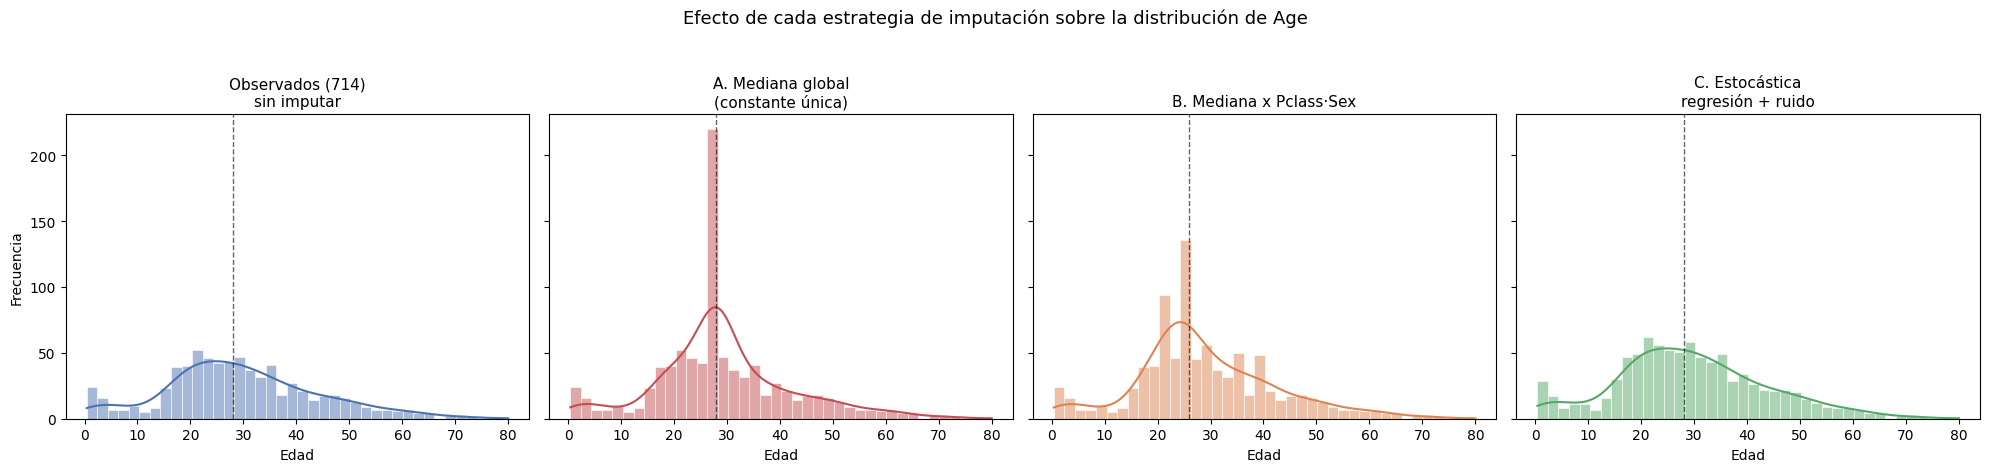

In [150]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharey=True)

paneles = [
    (edad_obs,    'Observados (714)\nsin imputar',        '#4C72B0'),
    (imp_global,  'A. Mediana global\n(constante única)', '#C44E52'),
    (imp_grupo,   'B. Mediana x Pclass·Sex',              '#DD8452'),
    (imp_estoc,   'C. Estocástica\nregresión + ruido',    '#55A868'),
]

for ax, (serie, titulo, color) in zip(axes, paneles):
    sns.histplot(serie, bins=40, kde=True, ax=ax, color=color, edgecolor='white', linewidth=.4)
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('Edad')
    ax.axvline(serie.median(), ls='--', lw=1, color='black', alpha=.6)

axes[0].set_ylabel('Frecuencia')
fig.suptitle('Efecto de cada estrategia de imputación sobre la distribución de Age', fontsize=13, y=1.04)
plt.tight_layout()
plt.show()

### Lectura de los resultados

Los paneles A y B muestran exactamente el problema que buscábamos evitar: una **barra anómala** que sobresale en el centro, donde se apilaron todos los valores imputados. En el panel C esa barra desaparece; la forma es indistinguible de la distribución original.

La curtosis lo cuantifica. Pasa de $0.178$ en los datos observados a $\approx 0.99$ con la mediana global — se multiplica por más de cinco. La imputación estocástica la deja en $\approx 0.13$, prácticamente intacta.

**Una advertencia honesta.** La imputación estocástica no gana en todas las métricas. La correlación entre `age` y `survived` se atenúa ligeramente más que con la mediana global ($-0.059$ frente a $-0.065$, partiendo de $-0.077$ en los observados). La razón es directa: el ruido $\varepsilon$ es aleatorio y por definición no está correlacionado con la supervivencia, así que diluye un poco la señal.

Ahora bien, esa correlación es débil desde el inicio y las tres opciones caen en un rango estrecho. La ganancia sólida y verificable de la imputación estocástica está en la **forma de la distribución**, no en la correlación puntual con la variable objetivo.

---

# 5. EDA sobre el dataset imputado

Con los nulos resueltos podemos repetir el análisis de edad usando las 891 filas completas, en vez de las 714 con edad conocida. Comparamos lado a lado para ver si la imputación alteró las conclusiones del EDA.

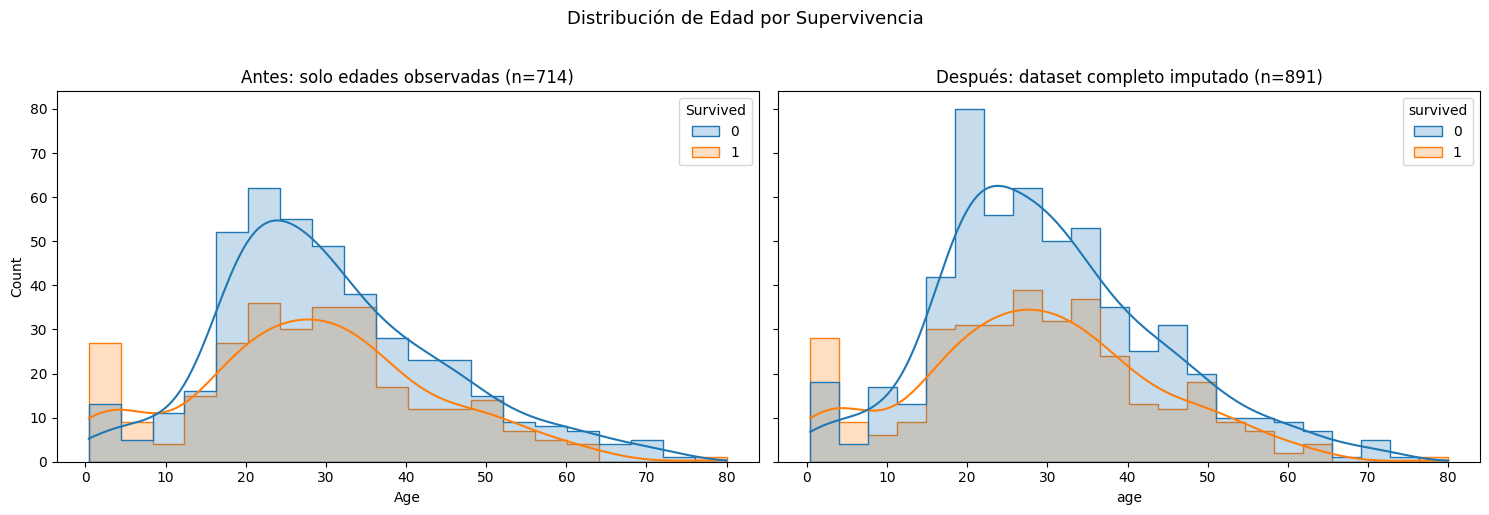

In [151]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

sns.histplot(data=df, x='Age', hue='Survived', kde=True, element='step', ax=axes[0])
axes[0].set_title(f'Antes: solo edades observadas (n={n_obs})')

sns.histplot(data=df_clean, x='age', hue='survived', kde=True, element='step', ax=axes[1])
axes[1].set_title(f'Después: dataset completo imputado (n={len(df_clean)})')

fig.suptitle('Distribución de Edad por Supervivencia', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

## Nota sobre el flujo de trabajo

Este notebook es la versión **explicativa**: muestra el razonamiento detrás de cada decisión. Para el pipeline reproducible existe `clean.py`, que ejecuta exactamente esta misma lógica desde la terminal y escribe el resultado en disco:

```bash
python3 clean.py
```

Esa separación es deliberada. El notebook sirve para entender y justificar; el script sirve para ejecutar de forma repetible sin depender de que alguien corra las celdas en orden.